# 02 · MLP de línea de base para Δvᵢ

*Mis apuntes. Secciones 7 a 9 del curso: MLP, bucle de entrenamiento, regresión, funciones de pérdida, learning rate, DataLoader, guardar y cargar modelos.*

En el curso el ejemplo de regresión era `housing.csv`: cada fila una casa, cada columna una característica, y el target el precio. Acá hago **exactamente lo mismo**, pero:

- cada **fila** es un **átomo**;
- las **columnas** describen su entorno (especie, coordinación y unos descriptores radiales);
- el **target** es su Δvᵢ.

**¿Por qué una "línea de base"?** Antes de meterme con una red sobre grafos (GNN), quiero saber cuánto se puede lograr con algo simple. Si la GNN no le gana a un MLP sin message passing, no tiene sentido toda esa complejidad. De paso, con la ablación y el error en función de la temperatura veo qué información explica Δv y dónde no alcanza con mirar el entorno local.

## Imports: qué es cada cosa

Además de lo del 01 (`torch`, `numpy`, `matplotlib`, `freud`), acá aparecen las piezas para entrenar:

> **`torch.nn` (`nn`)**: las capas (`nn.Linear`, `nn.Dropout`), las activaciones (`nn.SiLU`, `nn.ReLU`), las pérdidas (`nn.HuberLoss`) y la clase base `nn.Module` de la que heredan todos los modelos.
>
> **`torch.optim` (`optim`)**: los optimizadores (`optim.Adam`), que son los que actualizan los pesos usando los gradientes, y los *schedulers*, que cambian el learning rate durante el entrenamiento.
>
> **`TensorDataset`**: envuelve tensores `X` e `y` para que se puedan pedir de a una fila: `ds[i]` → `(X[i], y[i])`.
>
> **`DataLoader`**: toma un dataset y lo sirve en **mini-batches** (por ejemplo, de a 256 filas), mezclando el orden en cada época si `shuffle=True`.
>
> **`copy`**: librería estándar de Python. `copy.deepcopy` hace una copia completa e independiente de un objeto; la uso para guardar "una foto" de los mejores pesos.

`device` es `"cuda"` si hay GPU y `"cpu"` si no. Lo defino una vez y lo uso en todo el notebook.

In [1]:
try:
    import freud
except ImportError:
    %pip install -q freud-analysis
    import freud

import copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(0)
np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| freud", freud.__version__, "|", device)

torch 2.12.0+cu130 | freud 3.5.0 | cpu


## Paso 1 · Generar los datos

Con una sola caja y una vacancia tengo 12 átomos interesantes: no alcanza para entrenar nada. Entonces genero **muchas configuraciones** con el mismo código del 01, variando:

- **σ térmico** entre 0.03 y 0.15 Å (de "frío" a "caliente");
- **entre 1 y 6 vacancias** por caja. Si quedan pegadas forman divacancias; está bien, también me interesan.

**Qué hace cada función de la celda:**

- `volumen_voronoi(pos)`: lo mismo que en el 01, con freud.
- `dif_pbc(d)`: la imagen mínima, para no repetirla.
- `generar_configuracion(sigma, n_vac)`: arma una caja, le pone temperatura y especies, calcula $V_\text{ideal}$ **antes** de sacar átomos, saca `n_vac` átomos al azar (`torch.randperm(N)[:n_vac]` = los primeros de una permutación al azar) y calcula Δv. También marca qué átomos son vecinos de alguna vacancia.

> **Importante:** `vecino_vac` es una etiqueta **solo para evaluar** (para medir el error en los átomos que importan). No se la paso a la red como entrada.

Cada configuración lleva su número (`conf`) para después separar train, val y test por configuración.

In [2]:
ELEMENTOS = ["Fe", "Co", "Cr", "Cu", "Ni"]
a, n = 3.6, 4
L = n * a
R_C_VEC = 3.0        # cutoff de 1ros vecinos (entre a/√2 y a)

base = torch.tensor([[0., 0., 0.], [.5, .5, 0.], [.5, 0., .5], [0., .5, .5]])
i = torch.arange(n, dtype=torch.float32)
celdas = torch.stack(torch.meshgrid(i, i, i, indexing="ij"), dim=-1).reshape(-1, 3)
POS_IDEAL = (celdas[:, None] + base[None]).reshape(-1, 3) * a       # (256, 3)

box = freud.box.Box.cube(L)
voro = freud.locality.Voronoi()

def volumen_voronoi(pos):
    pts = (pos - L / 2).numpy().astype(np.float32)
    return torch.from_numpy(voro.compute((box, pts)).volumes.copy()).float()

def dif_pbc(d):
    return d - L * torch.round(d / L)

def generar_configuracion(sigma, n_vac):
    N = POS_IDEAL.shape[0]
    pos = (POS_IDEAL + sigma * torch.randn(N, 3)) % L
    species = torch.randint(0, len(ELEMENTOS), (N,))
    V_ideal = volumen_voronoi(pos).mean()            # cristal perfecto a la misma T

    idx_vac = torch.randperm(N)[:n_vac]
    mantener = torch.ones(N, dtype=torch.bool)
    mantener[idx_vac] = False
    pos, species = pos[mantener], species[mantener]

    dv = (volumen_voronoi(pos) - V_ideal) / V_ideal

    # etiqueta auxiliar (solo para evaluar, NO es input): ¿es 1er vecino de alguna vacancia?
    d = dif_pbc(pos[:, None] - POS_IDEAL[idx_vac][None])            # (N', n_vac, 3)
    vecino_vac = (torch.linalg.norm(d, dim=-1) < R_C_VEC).any(dim=1)
    return pos, species, dv, vecino_vac

### Paso 2 · Descriptores G2: convertir el entorno en un vector

Un MLP necesita que **cada fila tenga siempre la misma cantidad de columnas**. Pero cada átomo tiene sus vecinos a distancias distintas y en distinto orden. ¿Cómo convierto "mis vecinos" en un vector fijo?

Uso las **funciones de simetría radiales de Behler-Parrinello (G2)**. Para cada átomo $i$ y cada centro $R_s$:

$$G_i(R_s) = \sum_j e^{-\eta (r_{ij} - R_s)^2} \, f_c(r_{ij}), \qquad f_c(r) = \tfrac{1}{2}\left[\cos\!\left(\tfrac{\pi r}{R_c}\right) + 1\right]$$

**Cómo lo entiendo:** pongo 15 "campanitas" gaussianas centradas en distancias $R_s$ entre 2 y 4.8 Å. Cada vecino suma en las campanitas que le quedan cerca. El resultado es como un **histograma suavizado de las distancias a los vecinos** (una RDF por átomo). La función de corte $f_c$ hace que los vecinos lejanos pesen cada vez menos y que en $R_c$ la contribución llegue a 0 sin saltos.

**Por qué sirven:** como solo usan distancias y una suma, no cambian si roto, traslado o reordeno los átomos. Y no necesitan una red de referencia.

**Paso a paso del código:** `r[..., None] - RS` es broadcasting `(N, N, 1) − (15,)` → `(N, N, 15)`: la distancia de cada par a cada centro. Multiplico por el corte y sumo sobre los vecinos (`dim=1`) → `(N, 15)`.

In [3]:
R_CUT = 5.0                                  # alcanza 1ra, 2da y 3ra capa FCC (2.55, 3.6, 4.4 Å)
RS = torch.linspace(2.0, 4.8, 15)            # centros de las gaussianas
ETA = 1 / (2 * 0.15**2)                      # ancho ~0.15 Å

def descriptores_G2(pos):
    r = torch.linalg.norm(dif_pbc(pos[:, None] - pos[None]), dim=-1)    # (N, N)
    mask = (r > 0) & (r < R_CUT)
    fc = 0.5 * (torch.cos(torch.pi * r / R_CUT) + 1) * mask             # (N, N)
    gauss = torch.exp(-ETA * (r[..., None] - RS) ** 2)                  # (N, N, 15)
    G = (gauss * fc[..., None]).sum(dim=1)                              # (N, 15)
    coord = ((r > 0) & (r < R_C_VEC)).sum(dim=1, keepdim=True).float()  # (N, 1)
    return G, coord

Ahora genero 80 configuraciones y las junto. Para cada una guardo un diccionario con todo (posiciones, descriptores, Δv, etc.). Al final, `cat("G")` concatena el tensor `"G"` de todas las configuraciones en uno solo, uno debajo del otro. `torch.full_like(dv, sigma)` crea un tensor con la misma forma que `dv` lleno del valor σ: así cada átomo "recuerda" de qué temperatura viene.

In [4]:
N_CONF = 80
filas = []
for c in range(N_CONF):
    sigma = float(np.random.uniform(0.03, 0.15))
    n_vac = int(np.random.randint(1, 7))
    pos, species, dv, vecino_vac = generar_configuracion(sigma, n_vac)
    G, coord = descriptores_G2(pos)
    filas.append(dict(pos=pos, G=G, coord=coord, species=species, dv=dv, vecino_vac=vecino_vac,
                      sigma=torch.full_like(dv, sigma), conf=torch.full_like(species, c)))

cat = lambda k: torch.cat([f[k] for f in filas])
G, coord, species = cat("G"), cat("coord"), cat("species")
dv, vecino_vac, sigma_at, conf = cat("dv"), cat("vecino_vac"), cat("sigma"), cat("conf")

print(f"{len(dv)} átomos en {N_CONF} configuraciones | {vecino_vac.sum().item()} vecinos de vacancia "
      f"({100 * vecino_vac.float().mean():.1f} %)")
print("G:", G.shape, "| coord:", coord.shape, "| dv:", dv.shape)

20223 átomos en 80 configuraciones | 2845 vecinos de vacancia (14.1 %)
G: torch.Size([20223, 15]) | coord: torch.Size([20223, 1]) | dv: torch.Size([20223])


### Mirar los datos antes de entrenar

Esto siempre conviene hacerlo. Me anoto dos cosas que se ven en los gráficos:

- **Está muy desbalanceado:** ~85 % de los átomos son "bulk" (lejos de toda vacancia) con Δv ≈ 0. Un modelo que diga siempre 0 tendría un MAE global bajísimo y no serviría para nada. Por eso voy a medir el error **por población** (bulk y vecinos de vacancia).
- **La temperatura ensucia:** con más σ, el Δv del bulk se ensancha y empieza a pisarse con el de los vecinos de vacancia.

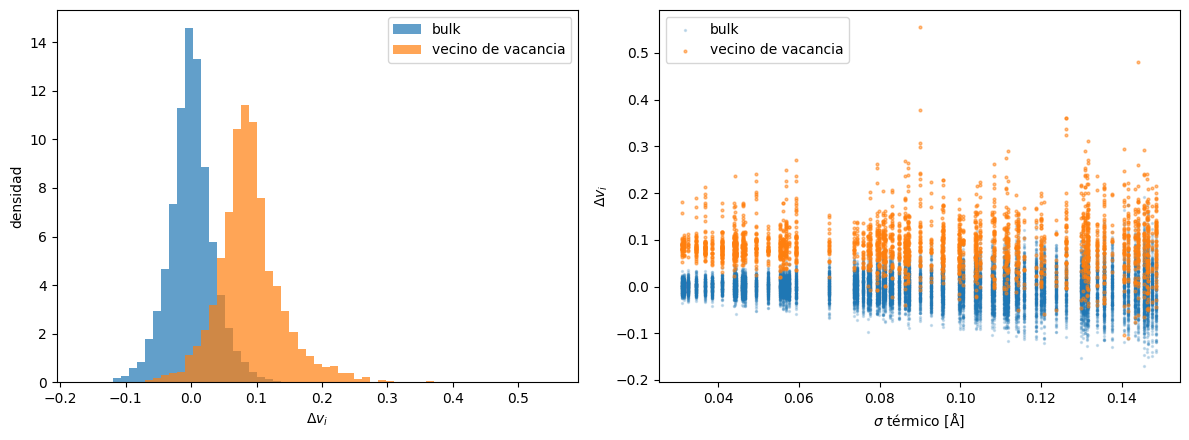

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
bins = torch.linspace(dv.min().item(), dv.max().item(), 60)
ax[0].hist(dv[~vecino_vac], bins=bins, alpha=0.7, density=True, label="bulk")
ax[0].hist(dv[vecino_vac], bins=bins, alpha=0.7, density=True, label="vecino de vacancia")
ax[0].set_xlabel(r"$\Delta v_i$"); ax[0].set_ylabel("densidad"); ax[0].legend()

ax[1].scatter(sigma_at[~vecino_vac], dv[~vecino_vac], s=2, alpha=0.2, label="bulk")
ax[1].scatter(sigma_at[vecino_vac], dv[vecino_vac], s=4, alpha=0.5, label="vecino de vacancia")
ax[1].set_xlabel(r"$\sigma$ térmico [Å]"); ax[1].set_ylabel(r"$\Delta v_i$"); ax[1].legend()
plt.tight_layout(); plt.show()

## Paso 3 · Armar X, y y separar train / val / test

- **X** = one-hot de especie (5) + coordinación (1) + G2 (15) = **21 columnas**.
- **y** = Δv **en porcentaje** (×100). Al optimizador le resultan más cómodos números del orden de 1 a 10 que 0.01, y así el MAE queda directo en %. `unsqueeze(1)` deja `y` con forma `(N, 1)`, igual que la salida de la red.

**El split es por configuración, no por átomo.** Esto es lo más importante del notebook. Si mezclo átomos al azar (como `train_test_split` en el curso), vecinos de la misma vacancia quedan unos en train y otros en test, y el test mide algo que el modelo "ya vio". Eso se llama **fuga de información (leakage)**. Con datos de simulación hay que separar siempre por configuración o por trayectoria.

**Cómo lo hago:** `torch.randperm(80)` mezcla los números de configuración; las primeras 56 van a train, 12 a val y 12 a test. `torch.isin(conf, conf_train)` da una máscara con `True` en los átomos cuya configuración está en train.

In [6]:
X = torch.cat([F.one_hot(species, len(ELEMENTOS)).float(), coord, G], dim=1)   # (N, 21)
y = (100 * dv).unsqueeze(1)                                                    # (N, 1), en %
NOMBRES = ELEMENTOS + ["coord"] + [f"G2(Rs={r:.1f})" for r in RS.tolist()]

perm = torch.randperm(N_CONF)
conf_train, conf_val, conf_test = perm[:56], perm[56:68], perm[68:]
m_train, m_val, m_test = (torch.isin(conf, s) for s in (conf_train, conf_val, conf_test))
print("átomos train/val/test:", m_train.sum().item(), m_val.sum().item(), m_test.sum().item())

átomos train/val/test: 14149 3042 3032


Guardo las configuraciones crudas y el split para que el notebook 03 use **exactamente los mismos datos y el mismo test**. Si no, no podría comparar los resultados. (El `|` entre diccionarios es la forma de Python 3.9+ de unirlos.)

In [7]:
from pathlib import Path
Path("datos").mkdir(exist_ok=True)
torch.save({
    "configs": [{k: f[k] for k in ("pos", "species", "dv", "vecino_vac")} | {"sigma": f["sigma"][0].item()}
                for f in filas],
    "conf_train": conf_train, "conf_val": conf_val, "conf_test": conf_test,
    "L": L, "a": a, "elementos": ELEMENTOS, "R_C_VEC": R_C_VEC,
}, "datos/02_dataset.pt")
print("guardado en datos/02_dataset.pt")

guardado en datos/02_dataset.pt


### Paso 4 · Estandarizar

Cada columna tiene una escala distinta (el one-hot va de 0 a 1, la coordinación ronda 12, los G2 pueden ser varios). Estandarizar es restar la media y dividir por el desvío, para que todas queden centradas en 0 con desvío 1. Así el optimizador no le da más importancia a una columna solo porque tiene números más grandes.

**Regla para recordar:** la media `mu` y el desvío `sd` se calculan **solo con train**. Si uso val o test, se filtra información. Lo hago a mano en vez de con `StandardScaler` porque son dos líneas y así puedo guardar `mu` y `sd` junto con el modelo. `clamp_min(1e-6)` evita dividir por 0 en una columna constante.

In [8]:
mu = X[m_train].mean(0)
sd = X[m_train].std(0).clamp_min(1e-6)     # evita dividir por 0 en columnas constantes
Xs = (X - mu) / sd

X_train, y_train = Xs[m_train], y[m_train]
X_val,   y_val   = Xs[m_val],   y[m_val]
X_test,  y_test  = Xs[m_test],  y[m_test]

## Paso 5 · El modelo

Igual que en el curso: una clase que hereda de `nn.Module`, con las capas en `__init__` y el cálculo en `forward`.

> **`nn.Sequential(...)`**: encadena capas; la salida de una es la entrada de la siguiente.
>
> **`nn.Linear(n_in, n_out)`**: capa densa, $y = Wx + b$. Es la que tiene los pesos que se aprenden.
>
> **`nn.Dropout(p)`**: durante el entrenamiento apaga al azar una fracción `p` de neuronas. Obliga a la red a no depender de una sola neurona (regularización). En evaluación no hace nada.

**Cambios respecto del curso, porque esto es regresión:**

- la **salida es lineal**, sin sigmoid ni softmax, porque Δv puede ser cualquier número, incluso negativo;
- uso **SiLU** ($x \cdot \sigma(x)$) en vez de ReLU: es suave (derivable en todos lados) y es la que se suele usar en modelos atómicos. Se puede cambiar por `nn.ReLU` para comparar;
- **dropout bajo** (0.05): son pocos parámetros y muchos datos.

`sum(p.numel() for p in model.parameters())` cuenta los parámetros que se van a entrenar.

In [9]:
class MLPDeltaV(nn.Module):
    def __init__(self, n_in, hidden=64, activation=nn.SiLU, p_drop=0.05):
        super().__init__()
        self.red = nn.Sequential(
            nn.Linear(n_in, hidden), activation(), nn.Dropout(p_drop),
            nn.Linear(hidden, hidden), activation(), nn.Dropout(p_drop),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.red(x)

model = MLPDeltaV(X.shape[1])
print(model)
print("parámetros:", sum(p.numel() for p in model.parameters()))

MLPDeltaV(
  (red): Sequential(
    (0): Linear(in_features=21, out_features=64, bias=True)
    (1): SiLU()
    (2): Dropout(p=0.05, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): SiLU()
    (5): Dropout(p=0.05, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)
parámetros: 5633


## Paso 6 · Entrenamiento

La función `entrenar` tiene el **bucle de siempre**. Me lo anoto porque es lo que más voy a repetir:

```
para cada época:
    model.train()                     # modo entrenamiento (dropout encendido)
    para cada batch (xb, yb):
        pred = model(xb)              # 1. forward
        loss = loss_fn(pred, yb)      # 2. calcular la pérdida
        optimizer.zero_grad()         # 3. borrar los gradientes del paso anterior
        loss.backward()               # 4. calcular gradientes (retropropagación)
        optimizer.step()              # 5. actualizar los pesos
    model.eval()                      # modo evaluación (dropout apagado)
    with torch.no_grad(): medir en val
```

El `zero_grad` hace falta porque PyTorch **acumula** los gradientes: si no los borro, se suman con los del batch anterior. Y `torch.no_grad()` le dice a PyTorch que no guarde lo necesario para calcular gradientes, porque en validación no los voy a usar (ahorra memoria y tiempo).

**Decisiones de este notebook:**

- **`HuberLoss`**: se comporta como MSE (cuadrática) para errores chicos y como MAE (lineal) para errores grandes. Así los pocos átomos con Δv muy grande (divacancias, alta T) no dominan el gradiente como pasaría con MSE.
- **Adam**: optimizador que adapta el paso para cada peso según la historia de sus gradientes. Es el que se usa por defecto.
- **`ReduceLROnPlateau`**: si el error de validación no mejora durante `patience` épocas, multiplica el learning rate por `factor` (0.5). Es como bajar la velocidad cuando uno se acerca al mínimo.
- **Me quedo con los mejores pesos en val** (`copy.deepcopy(model.state_dict())`). En la práctica es *early stopping*: aunque siga entrenando, devuelvo el modelo de la mejor época.

> **`state_dict()`**: diccionario con todos los pesos del modelo (nombre de la capa → tensor). Es lo que se guarda y se carga.

La armo como función porque la reuso en la ablación.

In [10]:
def entrenar(model, X_train, y_train, X_val, y_val, n_epochs=150, lr=3e-3, batch_size=256,
             loss_fn=nn.HuberLoss(delta=1.0), verbose=True):
    model = model.to(device)
    loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=10)
    Xv, yv = X_val.to(device), y_val.to(device)

    hist = {"train": [], "val": [], "lr": []}
    mejor, mejores_pesos = np.inf, None
    for epoch in range(n_epochs):
        model.train()                          # activa dropout
        perdidas = []
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = loss_fn(model(xb), yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            perdidas.append(loss.item())

        model.eval()                           # desactiva dropout
        with torch.no_grad():
            val_mae = (model(Xv) - yv).abs().mean().item()
        scheduler.step(val_mae)

        hist["train"].append(np.mean(perdidas)); hist["val"].append(val_mae)
        hist["lr"].append(optimizer.param_groups[0]["lr"])
        if val_mae < mejor:
            mejor, mejores_pesos = val_mae, copy.deepcopy(model.state_dict())
        if verbose and epoch % 25 == 0:
            print(f"epoch {epoch:3d}  train_loss={hist['train'][-1]:.4f}  val_MAE={val_mae:.4f} %  lr={hist['lr'][-1]:.1e}")

    model.load_state_dict(mejores_pesos)
    if verbose:
        print(f"mejor val MAE = {mejor:.4f} %")
    return model, hist

Entreno. Imprime cada 25 épocas el error de train (Huber), el MAE de validación en % y el learning rate actual.

In [11]:
model, hist = entrenar(MLPDeltaV(X.shape[1]), X_train, y_train, X_val, y_val)

epoch   0  train_loss=1.4834  val_MAE=0.4960 %  lr=3.0e-03


epoch  25  train_loss=0.2017  val_MAE=0.3133 %  lr=3.0e-03


epoch  50  train_loss=0.1916  val_MAE=0.3027 %  lr=7.5e-04


epoch  75  train_loss=0.1822  val_MAE=0.2865 %  lr=1.9e-04


epoch 100  train_loss=0.1849  val_MAE=0.2874 %  lr=4.7e-05


epoch 125  train_loss=0.1845  val_MAE=0.2861 %  lr=4.7e-05


mejor val MAE = 0.2855 %


**Cómo leer estas curvas.** A la izquierda, la pérdida de train y el MAE de validación (en escala log). Si val dejara de bajar mientras train sigue bajando, sería sobreajuste. A la derecha, el learning rate: cada escalón es una vez que `ReduceLROnPlateau` lo bajó a la mitad.

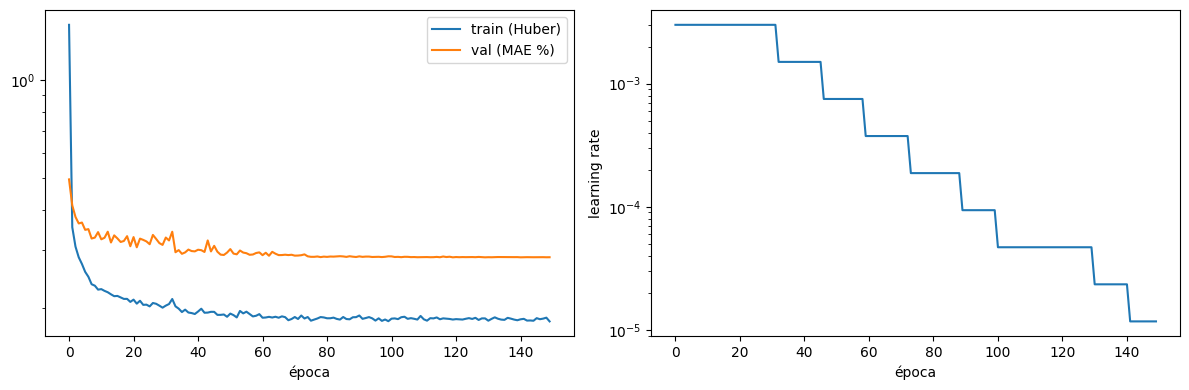

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(hist["train"], label="train (Huber)")
ax[0].plot(hist["val"], label="val (MAE %)")
ax[0].set_yscale("log"); ax[0].set_xlabel("época"); ax[0].legend()
ax[1].plot(hist["lr"]); ax[1].set_yscale("log"); ax[1].set_xlabel("época"); ax[1].set_ylabel("learning rate")
plt.tight_layout(); plt.show()

## Paso 7 · Evaluar en test

Lo que voy a mirar:

- **MAE global y por población**, comparado con un **modelo trivial** que predice siempre la media de train. Si mi MLP no le gana a eso, no aprendió nada.
- **Gráfico de paridad**: predicho vs real. Si fuera perfecto, todos los puntos caerían sobre la diagonal.
- **Detección**: si pongo un umbral (Δv predicho > 5 %), ¿encuentro a los vecinos de las vacancias? Esto es lo que después se va a usar para ubicar defectos.

`model.eval()` + `torch.no_grad()` para predecir, y `.cpu()` para traer el resultado a CPU (por si entrené en GPU).

In [13]:
model.eval()
with torch.no_grad():
    y_pred = model(X_test.to(device)).cpu()

vv_test = vecino_vac[m_test]
def mae(p, t): return (p - t).abs().mean().item()
trivial = torch.full_like(y_test, y_train.mean().item())

print(f"{'':22s}{'MLP':>10s}{'trivial':>10s}")
for nombre, m in [("global", slice(None)), ("bulk", ~vv_test), ("vecinos de vacancia", vv_test)]:
    print(f"MAE {nombre:18s}{mae(y_pred[m], y_test[m]):9.3f}%{mae(trivial[m], y_test[m]):9.3f}%")

                             MLP   trivial
MAE global                0.410%    3.742%
MAE bulk                  0.301%    3.050%
MAE vecinos de vacancia    1.033%    7.669%


Gráfico de paridad. `ax.set_aspect("equal")` hace que los dos ejes tengan la misma escala, si no la diagonal no se ve a 45°.

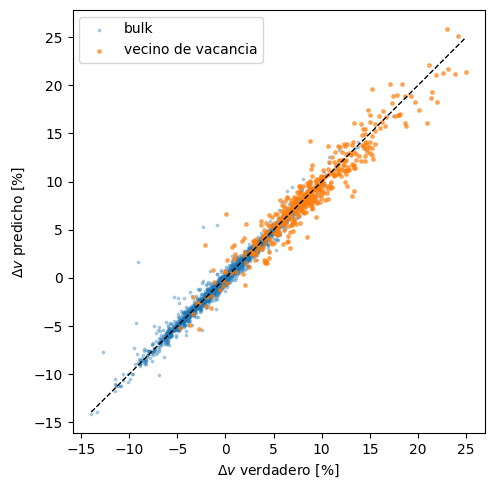

In [14]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(y_test[~vv_test], y_pred[~vv_test], s=3, alpha=0.3, label="bulk")
ax.scatter(y_test[vv_test], y_pred[vv_test], s=6, alpha=0.6, label="vecino de vacancia")
lim = [y_test.min().item(), y_test.max().item()]
ax.plot(lim, lim, "k--", lw=1)
ax.set_xlabel(r"$\Delta v$ verdadero [%]"); ax.set_ylabel(r"$\Delta v$ predicho [%]"); ax.legend()
ax.set_aspect("equal"); plt.show()

**Precisión y recall**, para recordar qué es cada uno:

- **precisión** = de los átomos que marqué como "vecino de vacancia", ¿qué fracción lo era de verdad? (pocos falsos positivos)
- **recall** = de todos los vecinos de vacancia que había, ¿qué fracción encontré? (pocos falsos negativos)

`tp` son los verdaderos positivos (marcados y reales). El `max(..., 1)` evita dividir por cero.

In [15]:
def precision_recall(score, verdad, umbral):
    pred = score > umbral
    tp = (pred & verdad).sum().item()
    return tp / max(pred.sum().item(), 1), tp / max(verdad.sum().item(), 1)

UMBRAL = 5.0   # %
for nombre, score in [("Δv verdadero (Voronoi)", y_test.squeeze()), ("Δv predicho (MLP)", y_pred.squeeze())]:
    p, r = precision_recall(score, vv_test, UMBRAL)
    print(f"{nombre:24s} precision={p:.3f}  recall={r:.3f}")

Δv verdadero (Voronoi)   precision=0.621  recall=0.808
Δv predicho (MLP)        precision=0.627  recall=0.791


**Cómo leo esta tabla:** la primera fila usa el **Δv exacto de Voronoi**, no una predicción. Es el **techo**: ni la etiqueta perfecta separa del todo a los vecinos de vacancia cuando la temperatura es alta. Si el MLP llega cerca de ese techo, el límite no es el modelo sino la etiqueta.

## Paso 8 · ¿Cómo cambia el error con la temperatura?

Divido el test en 4 rangos de σ y calculo el MAE de cada población en cada rango. `zip(bordes[:-1], bordes[1:])` recorre los pares de bordes consecutivos (lo, hi) de cada intervalo.

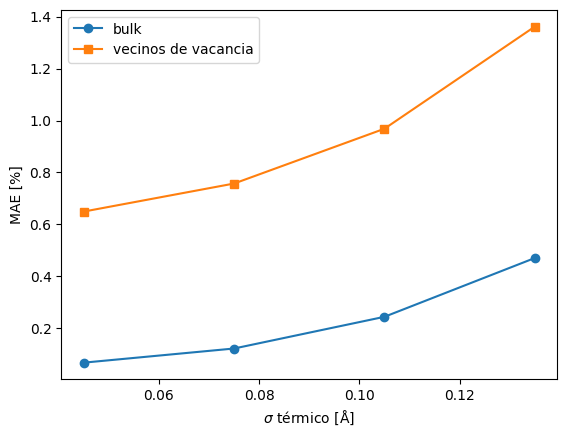

In [16]:
s_test = sigma_at[m_test]
bordes = torch.linspace(0.03, 0.15, 5)
centros, mae_bulk, mae_vac = [], [], []
for lo, hi in zip(bordes[:-1], bordes[1:]):
    m = (s_test >= lo) & (s_test < hi)
    if m.sum() == 0: continue
    centros.append(((lo + hi) / 2).item())
    mae_bulk.append(mae(y_pred[m & ~vv_test], y_test[m & ~vv_test]))
    mae_vac.append(mae(y_pred[m & vv_test], y_test[m & vv_test]))

plt.plot(centros, mae_bulk, "o-", label="bulk")
plt.plot(centros, mae_vac, "s-", label="vecinos de vacancia")
plt.xlabel(r"$\sigma$ térmico [Å]"); plt.ylabel("MAE [%]"); plt.legend(); plt.show()

## Paso 9 · Ablación: ¿qué columnas aportan?

Una **ablación** es entrenar el mismo modelo sacándole partes, para ver cuánto aporta cada una. Pruebo con tres conjuntos de columnas:

- solo especie;
- especie + coordinación;
- todo (con los G2).

Lo que espero: acá todas las especies tienen el mismo tamaño (las generé al azar sobre la misma red), así que la especie sola no debería aportar nada. En la HEA real (potencial EAM, datos de Deluigi) el Cr y el Cu tienen otro volumen atómico y ahí sí debería servir. **Pendiente:** repetirlo con esos datos.

`X_train[:, cols]` selecciona solo esas columnas. Fijo la semilla antes de cada entrenamiento para que la comparación sea justa.

In [17]:
variantes = {
    "especie":        list(range(0, 5)),
    "+ coordinación": list(range(0, 6)),
    "completo":       list(range(0, X.shape[1])),
}
resultados = {}
for nombre, cols in variantes.items():
    torch.manual_seed(0)
    m, _ = entrenar(MLPDeltaV(len(cols)), X_train[:, cols], y_train, X_val[:, cols], y_val, verbose=False)
    m.eval()
    with torch.no_grad():
        p = m(X_test[:, cols].to(device)).cpu()
    resultados[nombre] = (mae(p[~vv_test], y_test[~vv_test]), mae(p[vv_test], y_test[vv_test]))
    print(f"{nombre:16s} MAE bulk={resultados[nombre][0]:.3f}%  MAE vecinos vacancia={resultados[nombre][1]:.3f}%")

especie          MAE bulk=2.842%  MAE vecinos vacancia=8.521%


+ coordinación   MAE bulk=3.046%  MAE vecinos vacancia=3.466%


completo         MAE bulk=0.298%  MAE vecinos vacancia=1.032%


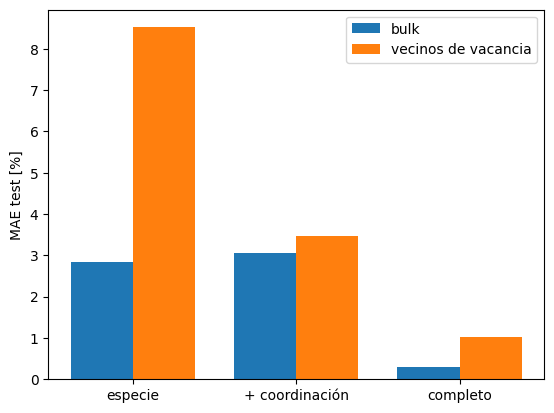

In [18]:
x = np.arange(len(resultados)); w = 0.38
plt.bar(x - w/2, [v[0] for v in resultados.values()], w, label="bulk")
plt.bar(x + w/2, [v[1] for v in resultados.values()], w, label="vecinos de vacancia")
plt.xticks(x, resultados.keys()); plt.ylabel("MAE test [%]"); plt.legend(); plt.show()

## Paso 10 · Guardar y cargar el modelo

Lo que aprendí a las malas: **guardar solo los pesos no alcanza**. Sin `mu` y `sd`, no sé cómo normalizar un dato nuevo, y el modelo da cualquier cosa. Entonces guardo en un solo diccionario:

- `state_dict` (los pesos),
- `n_in` (para poder volver a crear la arquitectura),
- `mu`, `sd` (la normalización),
- los parámetros del descriptor (`R_CUT`, `RS`, ...), porque si cambian, las columnas cambian,
- los nombres de las columnas y qué es el target.

Para cargar: creo un modelo nuevo vacío, `load_state_dict(...)`, `eval()`, y verifico con `torch.allclose` que predice exactamente lo mismo que el original.

In [19]:
checkpoint = {
    "state_dict": model.cpu().state_dict(),
    "n_in": X.shape[1], "mu": mu, "sd": sd, "columnas": NOMBRES,
    "descriptor": {"R_CUT": R_CUT, "RS": RS, "ETA": ETA, "R_C_VEC": R_C_VEC},
    "target": "100 * Δv  (porcentaje)",
}
torch.save(checkpoint, "datos/02_mlp_baseline.pt")

# Cargar en un modelo nuevo y verificar que predice lo mismo
ck = torch.load("datos/02_mlp_baseline.pt")
nuevo = MLPDeltaV(ck["n_in"]); nuevo.load_state_dict(ck["state_dict"]); nuevo.eval()
with torch.no_grad():
    print("mismas predicciones:", torch.allclose(nuevo(X_test), y_pred, atol=1e-5))

mismas predicciones: True


Prueba final: le paso la caja del notebook 01, que el modelo **nunca vio**. Tengo que calcular los descriptores con la misma función y normalizar con los `mu` y `sd` guardados en el checkpoint. Si el archivo del 01 no está (por ejemplo, en un Colab nuevo), la celda avisa en vez de fallar.

In [20]:
if Path("datos/01_fcc_vacancia.pt").exists():
    d01 = torch.load("datos/01_fcc_vacancia.pt")
    G01, coord01 = descriptores_G2(d01["pos"])
    X01 = torch.cat([F.one_hot(d01["species"], 5).float(), coord01, G01], dim=1)
    with torch.no_grad():
        p01 = nuevo((X01 - ck["mu"]) / ck["sd"]).squeeze()
    v = d01["vecino_vacancia"]
    print(f"vecinos de la vacancia: Δv real={100*d01['y'][v].mean():.2f}%  predicho={p01[v].mean():.2f}%")
    print(f"resto:                  Δv real={100*d01['y'][~v].mean():.2f}%  predicho={p01[~v].mean():.2f}%")
else:
    print("Subí datos/01_fcc_vacancia.pt (lo genera el notebook 01) para probar esta celda.")

vecinos de la vacancia: Δv real=9.29%  predicho=9.40%
resto:                  Δv real=-0.05%  predicho=-0.03%


## Lo que me llevo de este notebook

- El **bucle de entrenamiento** de 5 pasos (forward, pérdida, `zero_grad`, `backward`, `step`) es siempre el mismo. Lo que cambia es el modelo, la pérdida y los datos.
- **Split por configuración**, siempre. Y normalizar con estadísticas de train.
- **Medir por población**: el error global engaña cuando los datos están desbalanceados.
- **Guardar todo lo necesario** para usar el modelo después, no solo los pesos.

**Conclusión para la tesis:** los G2 son locales y fijos (5 Å, armados a mano). Una GNN de L capas aprende sus propios descriptores y ve L saltos de vecinos. Donde debería ganar es justo donde el MLP falla: alta temperatura y entornos más complicados (divacancias, clusters).

Igual hay que comparar contra el techo del Paso 7. Si a alta T ni el Δv exacto separa las vacancias, el problema está en la etiqueta. Esto se relaciona con la duda que dejé en CONTEXTO.md de agregar la energía por átomo εᵢ.

## Para probar

- `HuberLoss` vs `MSELoss` vs `L1Loss`: ¿cambia el MAE de los vecinos de vacancia?
- `ReLU` en vez de `SiLU`: ¿qué pasa con la paridad?
- Split por átomo (`randperm` sobre átomos) y comparar el MAE de test. Si da mejor, es el leakage.
- Agregar G4 (angulares) o sumar los G2 de los vecinos. Lo segundo es un paso de *message passing* hecho a mano: el puente a la GNN.